In [3]:

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Python version:", sys.version.split()[0])
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

import sklearn
print("scikit-learn version:", sklearn.__version__)

import tensorflow as tf
print("TensorFlow version:", tf.__version__)



gpu_devices = tf.config.list_physical_devices("GPU")
if gpu_devices:
    print(f"\n✅ GPU available: {gpu_devices[0].name} — Project 2 will run faster.")
else:
    print("\nℹ️ No GPU detected — everything will still run, just a bit slower on Project 2.")
    print("   In Colab: Runtime → Change runtime type → Hardware accelerator → GPU")

print("\nAll core libraries imported successfully. You're ready to go! 🚀")

Python version: 3.13.7
NumPy version: 2.3.3
Pandas version: 2.3.2
scikit-learn version: 1.7.2
TensorFlow version: 2.21.0

ℹ️ No GPU detected — everything will still run, just a bit slower on Project 2.
   In Colab: Runtime → Change runtime type → Hardware accelerator → GPU

All core libraries imported successfully. You're ready to go! 🚀


In [5]:
positive_reviews = [
    "Everyone agreed the ending was excellent",
    "I found the script to be wonderful",
    "The show turned out to be surprisingly brilliant",
    "I really loved how wonderful the performance was",
    "Everyone agreed the movie was fantastic",
    "I really loved how fantastic the direction was",
    "Everyone agreed this film was lovely",
    "I found the movie to be beautiful",
    "The acting was fun",
    "Everyone agreed the performance was beautiful",
    "The movie was impressive",
    "What a excellent show",
    "I found the direction to be excellent",
    "The performance was truly superb from start to finish",
    "I really loved how beautiful this film was",
    "I found the ending to be brilliant",
    "Everyone agreed the screenplay was refreshing",
    "The ending was engaging and kept me hooked",
    "I really loved how superb the ending was",
    "I really loved how stunning the story was",
    "What a beautiful film",
    "The show turned out to be surprisingly great",
    "What a engaging series",
    "I found the performance to be fantastic",
    "The show was truly heartwarming from start to finish",
    "The ending was excellent and kept me hooked",
    "I found the direction to be wonderful",
    "The show turned out to be surprisingly beautiful",
    "The ending turned out to be surprisingly stunning",
    "The performance was great and kept me hooked",
    "What a fantastic film",
    "I found the screenplay to be stunning",
    "What a solid movie",
    "The script was beautiful and kept me hooked",
    "Everyone agreed the plot was stunning",
    "The script was captivating",
    "The screenplay was truly captivating from start to finish",
    "The performance was brilliant and kept me hooked",
    "What a delightful movie",
    "I really loved how solid the story was",
    "The direction was remarkable and kept me hooked",
    "This film was outstanding and kept me hooked",
    "What a lovely direction",
    "What a heartwarming story",
    "This series turned out to be surprisingly heartwarming",
    "I really loved how remarkable the script was",
    "The story was truly fantastic from start to finish",
    "I really loved how impressive the story was",
    "The movie was truly great from start to finish",
    "The plot was superb",
    "The story turned out to be surprisingly heartwarming",
    "The performance turned out to be surprisingly beautiful",
    "The story was stunning",
    "Everyone agreed the screenplay was flawless",
    "Everyone agreed the direction was remarkable",
    "Everyone agreed this film was great",
    "I found the movie to be delightful",
    "The acting was truly engaging from start to finish",
    "This film was charming",
    "This film was truly amazing from start to finish",
    "I found the performance to be amazing",
    "Everyone agreed the acting was satisfying",
    "What a fun story",
    "The ending turned out to be surprisingly satisfying",
    "I found the screenplay to be brilliant",
    "The screenplay was engaging and kept me hooked",
    "I found the screenplay to be superb",
    "The story turned out to be surprisingly brilliant",
    "This series was enjoyable and kept me hooked",
    "This series was outstanding",
    "The acting turned out to be surprisingly good",
    "I found the show to be superb",
    "This series turned out to be surprisingly enjoyable",
    "I really loved how captivating the story was",
    "The show turned out to be surprisingly lovely",
    "I really loved how impressive the script was",
    "I really loved how remarkable the acting was",
    "The acting was good and kept me hooked",
    "The ending was solid",
    "The movie was enjoyable and kept me hooked",
    "The plot turned out to be surprisingly delightful",
    "The screenplay turned out to be surprisingly solid",
    "I really loved how fantastic the ending was",
    "This film was impressive and kept me hooked",
    "I really loved how charming the acting was",
    "The screenplay was satisfying",
    "The screenplay turned out to be surprisingly fun",
    "I found the script to be fantastic",
    "I really loved how stunning the direction was",
    "Everyone agreed the screenplay was outstanding",
    "I found the script to be charming",
    "This series was remarkable and kept me hooked",
    "I found the direction to be solid",
    "This series was truly outstanding from start to finish",
    "The story was truly amazing from start to finish",
    "The performance was truly engaging from start to finish",
    "The performance was satisfying and kept me hooked",
    "The script was truly captivating from start to finish",
    "The show was truly lovely from start to finish",
    "I found the movie to be amazing",
    "The show was truly solid from start to finish",
    "I really loved how delightful the direction was",
    "I really loved how enjoyable the movie was",
    "I really loved how good the plot was",
    "What a charming performance",
    "The movie turned out to be surprisingly solid",
    "The show was truly excellent from start to finish",
    "The show was good",
    "The screenplay was truly flawless from start to finish",
    "The performance was truly amazing from start to finish",
    "I absolutely loved this movie",
    "This film was amazing and brilliant",
    "What a fantastic experience",
    "The acting was excellent",
    "I really enjoyed the story",
    "This was a wonderful movie",
]

negative_reviews = [
    "The story was dull and I lost interest quickly",
    "I found the performance to be tiresome",
    "The show turned out to be surprisingly terrible",
    "The script was poor and I lost interest quickly",
    "This film was unpleasant",
    "What a tedious acting",
    "I found the movie to be disgusting",
    "The show was frustrating",
    "This film turned out to be surprisingly frustrating",
    "I really disliked how poor the performance was",
    "This series was forgettable and I lost interest quickly",
    "The show was unpleasant and I lost interest quickly",
    "What a unconvincing show",
    "The show was tedious and I lost interest quickly",
    "I found the story to be underwhelming",
    "The direction turned out to be surprisingly frustrating",
    "I really disliked how sloppy this film was",
    "I really disliked how boring the direction was",
    "I found the script to be mediocre",
    "The story turned out to be surprisingly flat",
    "The story was truly forgettable from start to finish",
    "I found the screenplay to be unconvincing",
    "The direction was truly bad from start to finish",
    "The script was truly unconvincing from start to finish",
    "Everyone agreed this series was underwhelming",
    "I really disliked how underwhelming the ending was",
    "I found the ending to be annoying",
    "This series was confusing",
    "The ending was unpleasant and I lost interest quickly",
    "The screenplay was flat",
    "What a annoying direction",
    "I found the show to be boring",
    "I found the acting to be disappointing",
    "The plot was forgettable",
    "What a sloppy direction",
    "The direction was dull and I lost interest quickly",
    "I found this series to be annoying",
    "The plot was truly terrible from start to finish",
    "What a boring direction",
    "I found the movie to be dreadful",
    "I really disliked how boring the plot was",
    "I found this film to be forgettable",
    "The screenplay turned out to be surprisingly awful",
    "What a underwhelming show",
    "The performance was dull",
    "I really disliked how flat the show was",
    "What a horrible film",
    "I really disliked how horrible the movie was",
    "What a dreadful plot",
    "I really disliked how disgusting the show was",
    "The plot was truly frustrating from start to finish",
    "The plot was confusing",
    "The plot was terrible",
    "I really disliked how tiresome the movie was",
    "I really disliked how bad the show was",
    "Everyone agreed the screenplay was disappointing",
    "Everyone agreed the script was bad",
    "I really disliked how mediocre the show was",
    "I really disliked how annoying the acting was",
    "This series was truly tiresome from start to finish",
    "The direction was confusing",
    "I found the story to be awful",
    "What a tiresome script",
    "The direction was horrible",
    "Everyone agreed this film was sloppy",
    "What a sloppy show",
    "What a unconvincing performance",
    "The movie was truly frustrating from start to finish",
    "The story was forgettable and I lost interest quickly",
    "The movie turned out to be surprisingly forgettable",
    "The ending turned out to be surprisingly unpleasant",
    "What a terrible acting",
    "The acting was truly confusing from start to finish",
    "Everyone agreed the movie was annoying",
    "What a bad film",
    "I really disliked how dreadful the show was",
    "The acting was poor",
    "The story was lifeless",
    "What a awful direction",
    "I really disliked how dreadful the plot was",
    "This film was truly disastrous from start to finish",
    "Everyone agreed the script was flat",
    "The ending was tiresome and I lost interest quickly",
    "The story was truly mediocre from start to finish",
    "Everyone agreed the movie was flat",
    "This series was truly flat from start to finish",
    "The show was disgusting",
    "I really disliked how disastrous the script was",
    "This film was awful",
    "The story turned out to be surprisingly dreadful",
    "This film was lifeless and I lost interest quickly",
    "The show was terrible",
    "I really disliked how unpleasant the script was",
    "The screenplay was forgettable",
    "I found the screenplay to be boring",
    "I found the script to be poor",
    "This series was tiresome and I lost interest quickly",
    "What a boring plot",
    "I really disliked how tiresome the acting was",
    "The acting was tiresome and I lost interest quickly",
    "I found the screenplay to be lifeless",
    "What a sloppy screenplay",
    "I really disliked how weak the movie was",
    "This film was truly weak from start to finish",
    "What a forgettable ending",
    "The performance was truly disastrous from start to finish",
    "The movie was bad",
    "I found the screenplay to be forgettable",
    "This series was tedious and I lost interest quickly",
    "What a flat plot",
    "I hated this movie",
    "This film was terrible and boring",
    "What a horrible experience",
    "The acting was awful",
    "I really disliked the story",
    "This was a complete waste of time",
]

reviews = positive_reviews + negative_reviews
labels = [1] * len(positive_reviews) + [0] * len(negative_reviews)

sentiment_df = pd.DataFrame({
    "review": reviews,
    "sentiment": labels
})

print("Total reviews:", len(sentiment_df))
sentiment_df.head()

Total reviews: 232


,review,sentiment
0,Everyone agreed the ending was excellent,1
1,I found the script to be wonderful,1
2,The show turned out to be surprisingly brilliant,1
3,I really loved how wonderful the performance was,1
4,Everyone agreed the movie was fantastic,1


In [6]:
print("Dataset shape:", sentiment_df.shape)
print("\nClass distribution:")
print(sentiment_df["sentiment"].value_counts())
display(sentiment_df.head())

Dataset shape: (232, 2)

Class distribution:
sentiment
1    116
0    116
Name: count, dtype: int64


,review,sentiment
0,Everyone agreed the ending was excellent,1
1,I found the script to be wonderful,1
2,The show turned out to be surprisingly brilliant,1
3,I really loved how wonderful the performance was,1
4,Everyone agreed the movie was fantastic,1


In [7]:
from sklearn.model_selection import train_test_split

X_text = sentiment_df["review"]
y_sentiment = sentiment_df["sentiment"]

X_train_text, X_test_text, y_train_sentiment, y_test_sentiment = train_test_split(
    X_text, y_sentiment,
    test_size=0.25,
    random_state=42,
    stratify=y_sentiment
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 174
Testing samples: 58


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

Training matrix shape: (174, 77)
Testing matrix shape: (58, 77)


In [9]:
from sklearn.linear_model import LogisticRegression

sentiment_model = LogisticRegression(random_state=42)
sentiment_model.fit(X_train_tfidf, y_train_sentiment)

print("Sentiment model trained successfully.")

Sentiment model trained successfully.


Accuracy: 0.9828

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      0.97      0.98        29

    accuracy                           0.98        58
   macro avg       0.98      0.98      0.98        58
weighted avg       0.98      0.98      0.98        58



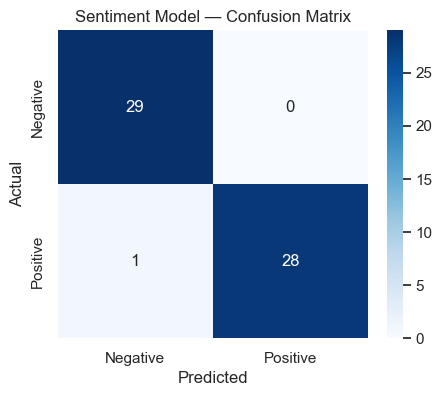

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sentiment_predictions = sentiment_model.predict(X_test_tfidf)

sentiment_accuracy = accuracy_score(
    y_test_sentiment,
    sentiment_predictions
)

print("Accuracy:", round(sentiment_accuracy, 4))
print("\nClassification Report:")
print(classification_report(
    y_test_sentiment,
    sentiment_predictions,
    zero_division=0
))

# Confusion matrix — a quick visual of where the model got confused
cm = confusion_matrix(y_test_sentiment, sentiment_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Model — Confusion Matrix")
plt.show()

In [12]:
def predict_sentiment(review):
    review_vector = vectorizer.transform([review])
    prediction = sentiment_model.predict(review_vector)[0]
    probability = sentiment_model.predict_proba(review_vector)[0].max()

    result = "Positive 😊" if prediction == 1 else "Negative 😞"
    return result, probability

test_reviews = [
    "The movie was absolutely fantastic",
    "This was boring and disappointing",
    "I loved the acting and the story"
]

for review in test_reviews:
    result, confidence = predict_sentiment(review)
    print("Review:", review)
    print("Prediction:", result)
    print("Confidence:", round(confidence * 100, 2), "%")
    print("-" * 60)

Review: The movie was absolutely fantastic
Prediction: Positive 😊
Confidence: 64.91 %
------------------------------------------------------------
Review: This was boring and disappointing
Prediction: Negative 😞
Confidence: 73.94 %
------------------------------------------------------------
Review: I loved the acting and the story
Prediction: Positive 😊
Confidence: 69.79 %
------------------------------------------------------------


In [13]:
my_review = "I thought the movie was exciting and wonderful"

result, confidence = predict_sentiment(my_review)

print("Your Review:", my_review)
print("AI Prediction:", result)
print("Confidence:", round(confidence * 100, 2), "%")

Your Review: I thought the movie was exciting and wonderful
AI Prediction: Positive 😊
Confidence: 62.39 %


In [14]:
while True:
    user_input = input("Type a movie review (or 'quit' to stop): ")
    if user_input.strip().lower() == "quit":
        print("Session ended.")
        break
    result, confidence = predict_sentiment(user_input)
    print("AI Prediction:", result, f"({confidence * 100:.1f}% confident)")
    print("-" * 60)

AI Prediction: Negative 😞 (51.9% confident)
------------------------------------------------------------
AI Prediction: Negative 😞 (51.9% confident)
------------------------------------------------------------
AI Prediction: Negative 😞 (51.9% confident)
------------------------------------------------------------
Session ended.


In [15]:
import pickle

with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(sentiment_model, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Model saved successfully!")

Model saved successfully!
